In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

from imblearn.over_sampling import SMOTE


In [2]:
!pip install imbalanced-learn



   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from imblearn.over_sampling import SMOTE


In [4]:
import imblearn
print(imblearn.__version__)


0.14.1


In [6]:
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_clusters_per_class=2,
    weights=[0.9, 0.1],   # 90% vs 10% (imbalanced)
    random_state=42
)

data = pd.DataFrame(X)
data['target'] = y

print(data.head())


          0         1         2         3         4         5         6  \
0  0.836084 -0.406200  0.985852 -1.098696  0.896335  0.755028 -1.412918   
1 -1.051926  2.785092 -0.296145 -1.540667 -0.044196 -0.262313 -0.244954   
2  0.958855 -0.294964 -0.599162 -2.020151  0.696867  2.054202  1.264476   
3 -1.959412  5.325782  0.953711 -1.972112  1.402063 -0.190190  0.385689   
4 -1.945330 -4.153046 -0.808245  0.836231 -1.757355 -0.974836 -1.006793   

          7         8         9  ...        11        12        13        14  \
0 -0.556318  0.570253  1.316120  ... -0.897290 -0.326756  2.159997 -0.100288   
1 -1.876305 -2.330663  2.831587  ...  0.648860 -0.720809 -0.555938  0.374713   
2 -0.387519 -0.821913 -0.539239  ...  0.722353  1.012499 -0.078173  0.586247   
3  2.337580  0.116479  0.747550  ...  0.716049 -2.588631 -1.988221  0.359436   
4 -2.172324  0.476773  3.802259  ...  2.543219  3.475602 -0.420226  1.008474   

         15        16        17        18        19  target  
0 -1.3

Original Class Distribution:
target
0    1792
1     208
Name: count, dtype: int64


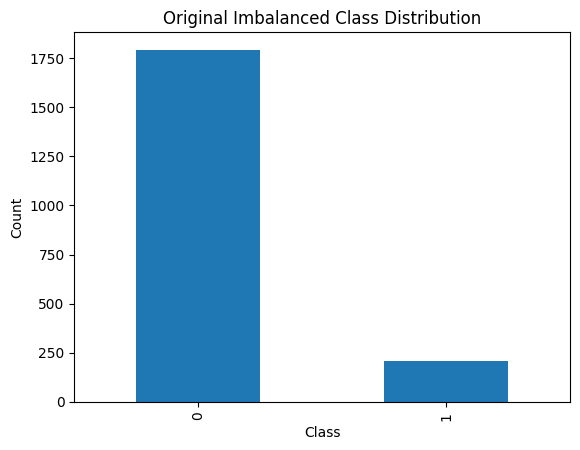

In [7]:
class_counts = data['target'].value_counts()

print("Original Class Distribution:")
print(class_counts)

plt.figure()
class_counts.plot(kind='bar')
plt.title("Original Imbalanced Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [8]:
X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)


In [9]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


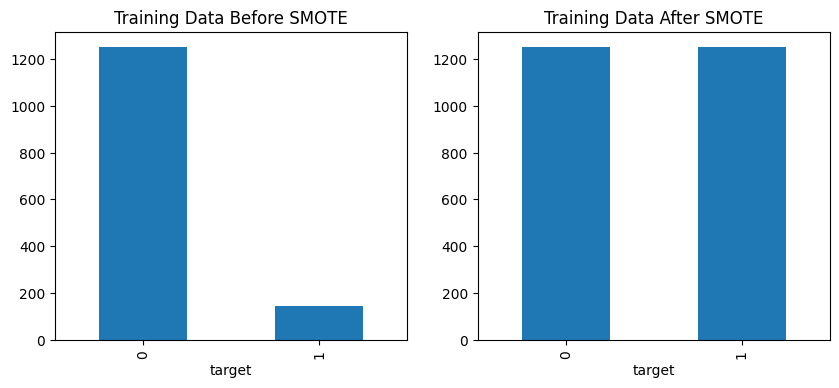

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
y_train.value_counts().plot(kind='bar')
plt.title("Training Data Before SMOTE")

plt.subplot(1,2,2)
pd.Series(y_train_smote).value_counts().plot(kind='bar')
plt.title("Training Data After SMOTE")

plt.show()


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)


In [12]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train_smote)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(X_test_scaled)


In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)


Accuracy: 0.8266666666666667
Precision: 0.35
Recall: 0.7903225806451613


In [15]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90       538
           1       0.35      0.79      0.49        62

    accuracy                           0.83       600
   macro avg       0.66      0.81      0.69       600
weighted avg       0.91      0.83      0.85       600

